In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

dataset_path = r"D:\Ai Models\MangoLeafDataset"

print("Dataset Path:")
print(dataset_path)

print("\nFolders:")
print(os.listdir(dataset_path))

Dataset Path:
D:\Ai Models\MangoLeafDataset

Folders:
['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


In [2]:
class_names = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Classes found:")
for i, name in enumerate(class_names):
    print(i, "-", name)

print("\nTotal Classes:", len(class_names))

Classes found:
0 - Anthracnose
1 - Bacterial Canker
2 - Cutting Weevil
3 - Die Back
4 - Gall Midge
5 - Healthy
6 - Powdery Mildew
7 - Sooty Mould

Total Classes: 8


In [3]:
class_counts = {}

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for class_name in class_names:

    class_path = os.path.join(dataset_path, class_name)

    count = 0

    for filename in os.listdir(class_path):

        if filename.lower().endswith(valid_extensions):
            count += 1

    class_counts[class_name] = count

print("CLASS DISTRIBUTION")
print("=" * 40)

for class_name, count in class_counts.items():
    print(f"{class_name:20s} : {count}")

print("\nTotal Images:", sum(class_counts.values()))

CLASS DISTRIBUTION
Anthracnose          : 500
Bacterial Canker     : 500
Cutting Weevil       : 500
Die Back             : 500
Gall Midge           : 500
Healthy              : 500
Powdery Mildew       : 500
Sooty Mould          : 500

Total Images: 4000


In [4]:
max_count = max(class_counts.values())
min_count = min(class_counts.values())

imbalance_ratio = max_count / min_count

print("Maximum class:", max_count)
print("Minimum class:", min_count)

print("Imbalance ratio:", round(imbalance_ratio, 2))

if imbalance_ratio == 1:
    print("Dataset is perfectly balanced.")
elif imbalance_ratio < 1.5:
    print("Dataset is reasonably balanced.")
else:
    print("Dataset has noticeable class imbalance.")

Maximum class: 500
Minimum class: 500
Imbalance ratio: 1.0
Dataset is perfectly balanced.


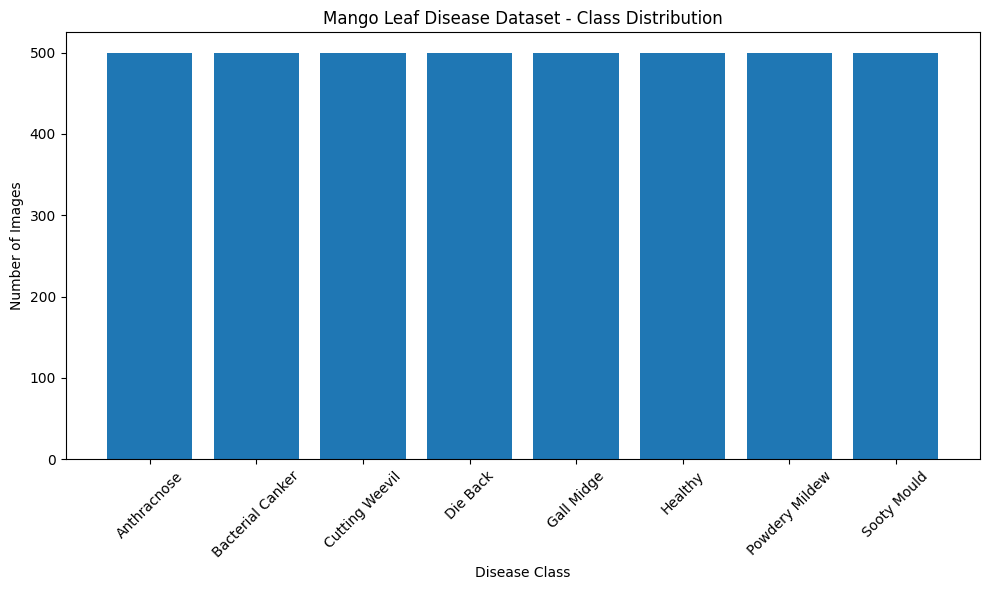

In [5]:
plt.figure(figsize=(10, 6))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title("Mango Leaf Disease Dataset - Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
corrupt_images = []

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    for filename in os.listdir(class_path):
        if filename.lower().endswith(valid_extensions):
            image_path = os.path.join(class_path, filename)
            try:
                with Image.open(image_path) as img:
                    img.verify()
            except Exception:
                corrupt_images.append(image_path)

print("Corrupt/unreadable images:", len(corrupt_images))
if len(corrupt_images) > 0:
    print("\nCorrupt files:")
    for path in corrupt_images:
        print(path)
else:
    print("No corrupt images found.")

Corrupt/unreadable images: 0
No corrupt images found.


In [8]:
widths = []
heights = []

for class_name in class_names:

    class_path = os.path.join(dataset_path, class_name)

    for filename in os.listdir(class_path):

        if filename.lower().endswith(valid_extensions):

            image_path = os.path.join(class_path, filename)

            try:

                with Image.open(image_path) as img:

                    width, height = img.size

                    widths.append(width)
                    heights.append(height)

            except:
                pass

print("IMAGE DIMENSION ANALYSIS")
print("=" * 40)

print("Width")
print("Min :", min(widths))
print("Max :", max(widths))
print("Mean:", round(np.mean(widths), 2))

print("\nHeight")
print("Min :", min(heights))
print("Max :", max(heights))
print("Mean:", round(np.mean(heights), 2))

IMAGE DIMENSION ANALYSIS
Width
Min : 187
Max : 320
Mean: 274.92

Height
Min : 70
Max : 320
Mean: 260.27


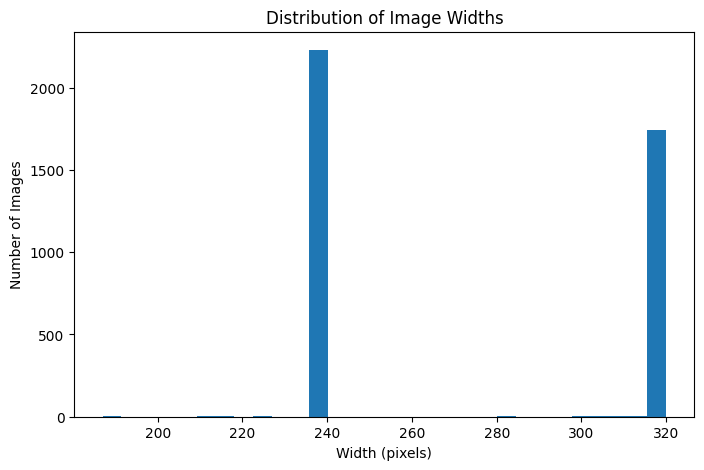

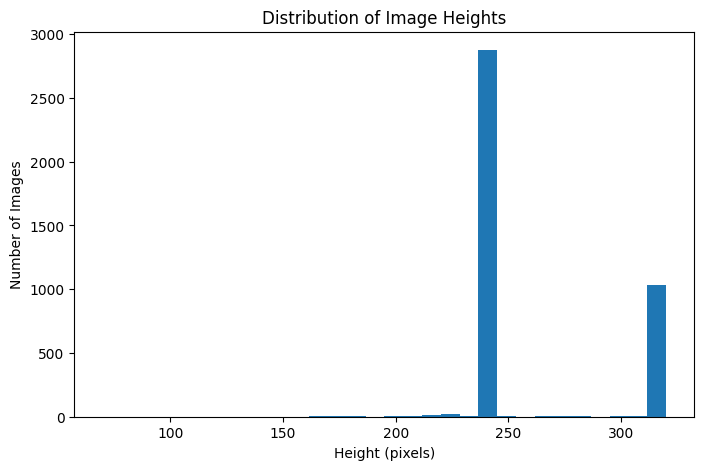

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(widths, bins=30)

plt.title("Distribution of Image Widths")
plt.xlabel("Width (pixels)")
plt.ylabel("Number of Images")

plt.show()

plt.figure(figsize=(8, 5))

plt.hist(heights, bins=30)

plt.title("Distribution of Image Heights")
plt.xlabel("Height (pixels)")
plt.ylabel("Number of Images")

plt.show()

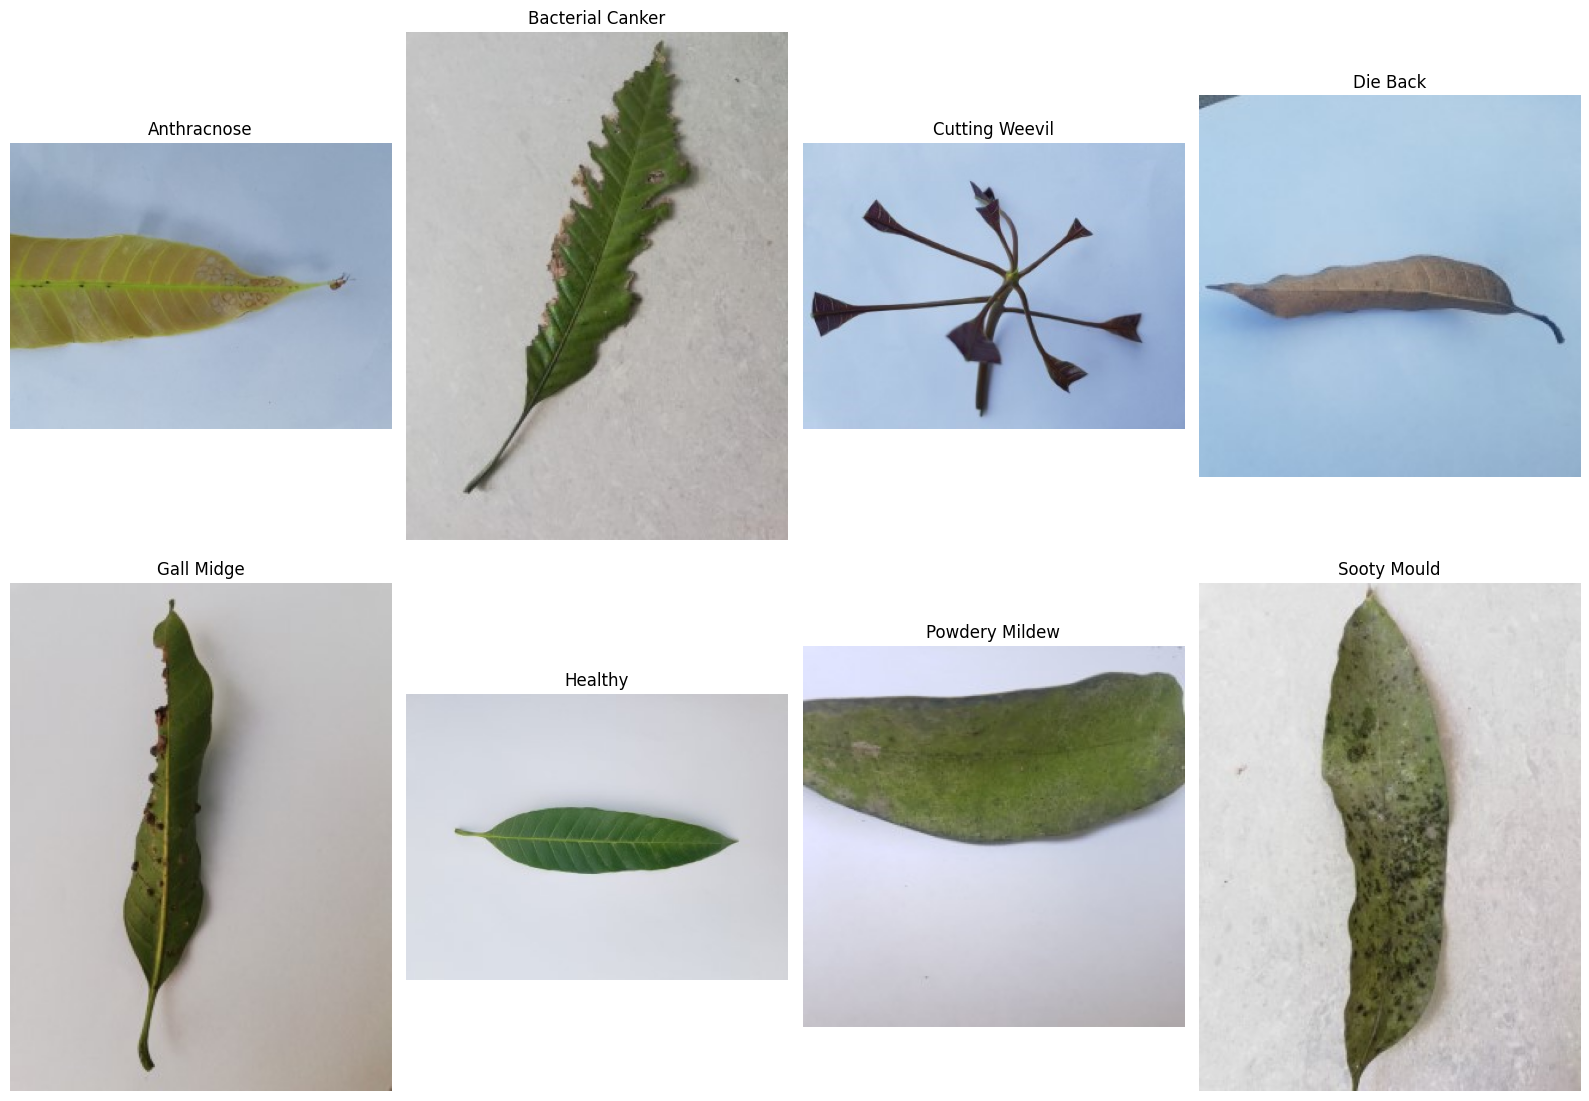

In [10]:
plt.figure(figsize=(16, 12))

for i, class_name in enumerate(class_names):

    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(valid_extensions)
    ]

    if len(image_files) == 0:
        continue

    image_path = os.path.join(
        class_path,
        image_files[0]
    )

    image = Image.open(image_path)

    plt.subplot(2, 4, i + 1)

    plt.imshow(image)

    plt.title(class_name)

    plt.axis("off")

plt.tight_layout()
plt.show()

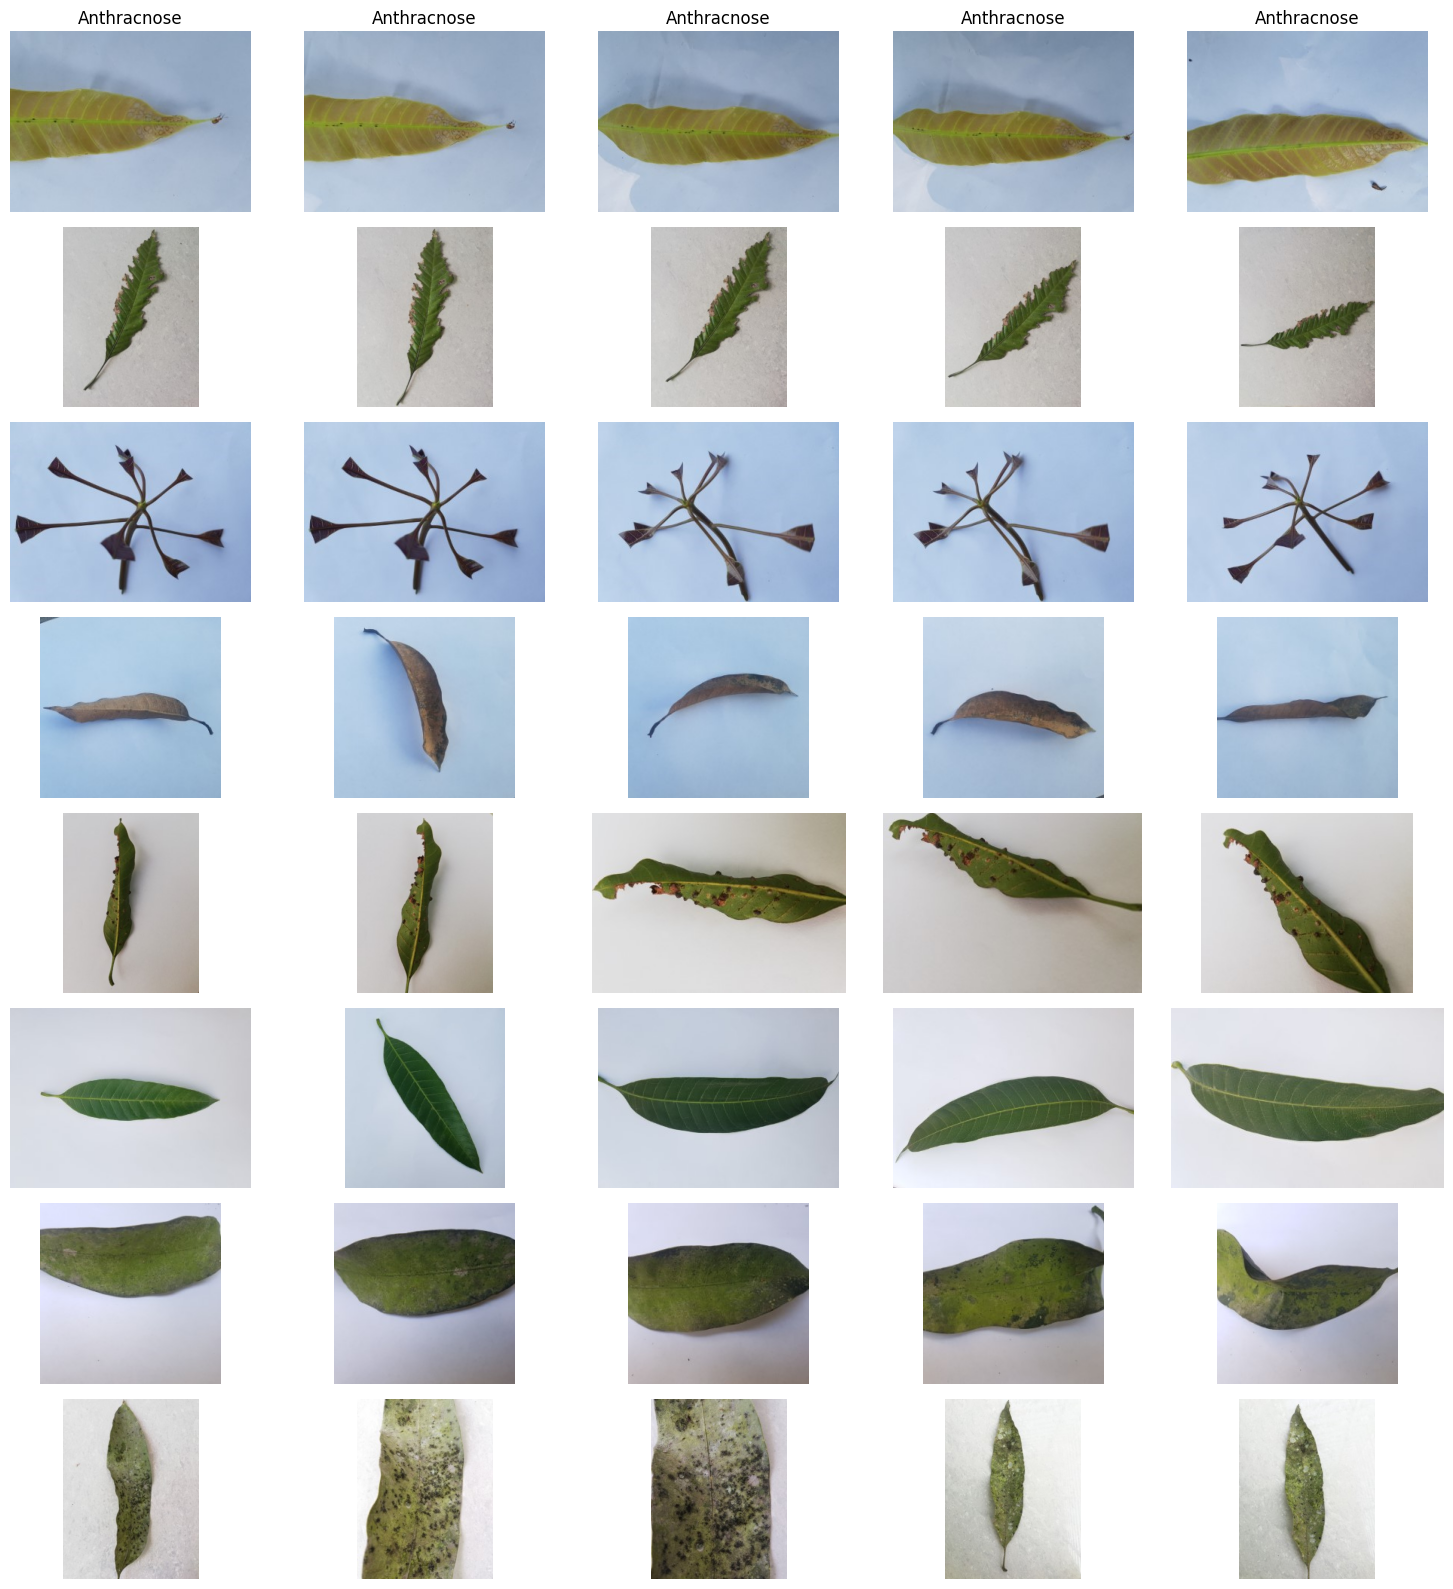

In [11]:
samples_per_class = 5

plt.figure(figsize=(15, 16))

plot_index = 1

for class_name in class_names:

    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(valid_extensions)
    ]

    selected_files = image_files[:samples_per_class]

    for filename in selected_files:

        image_path = os.path.join(
            class_path,
            filename
        )

        image = Image.open(image_path)

        plt.subplot(
            len(class_names),
            samples_per_class,
            plot_index
        )

        plt.imshow(image)

        if plot_index <= samples_per_class:
            plt.title(class_name)

        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

In [12]:
print("=" * 60)
print("MANGO LEAF DISEASE DATASET EDA SUMMARY")
print("=" * 60)

print("\nNumber of Classes :", len(class_names))

print("Total Images      :", sum(class_counts.values()))

print("\nClass Distribution:")

for class_name, count in class_counts.items():
    print(f"  {class_name:20s}: {count}")

print("\nImbalance Ratio   :", round(imbalance_ratio, 2))

print("Corrupt Images    :", len(corrupt_images))

print("\nImage Width:")
print("  Minimum :", min(widths))
print("  Maximum :", max(widths))
print("  Mean    :", round(np.mean(widths), 2))

print("\nImage Height:")
print("  Minimum :", min(heights))
print("  Maximum :", max(heights))
print("  Mean    :", round(np.mean(heights), 2))

print("\nEDA completed successfully.")

MANGO LEAF DISEASE DATASET EDA SUMMARY

Number of Classes : 8
Total Images      : 4000

Class Distribution:
  Anthracnose         : 500
  Bacterial Canker    : 500
  Cutting Weevil      : 500
  Die Back            : 500
  Gall Midge          : 500
  Healthy             : 500
  Powdery Mildew      : 500
  Sooty Mould         : 500

Imbalance Ratio   : 1.0
Corrupt Images    : 0

Image Width:
  Minimum : 187
  Maximum : 320
  Mean    : 274.92

Image Height:
  Minimum : 70
  Maximum : 320
  Mean    : 260.27

EDA completed successfully.
